PART III : Linear & Ridge Regressions using OLS
----------------------------------------------
----------------------------------------------

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Loading preprocessed data
data = pd.read_csv('../data/emissions_by_country_preprocessed.csv')

In [3]:
# Assuming 'Total' as  target variable
target_variable = 'Total'

# Defining features and target
features = data.drop([target_variable, 'Country', 'ISO 3166-1 alpha-3'], axis=1)
target = data[target_variable]

In [4]:
# Split data into training and testing sets (80% training, 20% testing)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

# Prints shapes
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)


X_train shape: (13164, 9)
y_train shape: (13164,)
X_test shape: (3292, 9)
y_test shape: (3292,)


In [5]:
#  Linear Regression using OLS
#  Calculates the weights with the OLS equation
def ols_regression_(X, y):
    X = X.to_numpy()
    y = y.to_numpy()
    beta = np.linalg.inv(X.T @ X) @ X.T @ y  # OLS equation
    return beta

# Compute weights
beta_ols = ols_regression_(X_train, y_train)

# Calculates predictions and compute the Mean Squared Error (MSE)
y_pred_ols = X_test.to_numpy() @ beta_ols
mse_ols = np.mean((y_test.to_numpy() - y_pred_ols) ** 2)

In [6]:
# Ridge Regression using OLS
# Implementing Ridge regression
def ridge_regression_(X, y, lambda_value):
    X = X.to_numpy()
    y = y.to_numpy()
    beta_ridge = np.linalg.inv(X.T @ X + lambda_value * np.identity(X.shape[1])) @ X.T @ y  # Ridge OLS equation
    return beta_ridge

# Choosing a lambda value (regularization parameter)
lambda_value = 0.00001

# Computes weights for Ridge Regression
beta_ridge = ridge_regression_(X_train, y_train, lambda_value)

# Calculate predictions and Mean Squared Error for Ridge
y_pred_ridge = X_test.to_numpy() @ beta_ridge
mse_ridge = np.mean((y_test.to_numpy() - y_pred_ridge) ** 2)



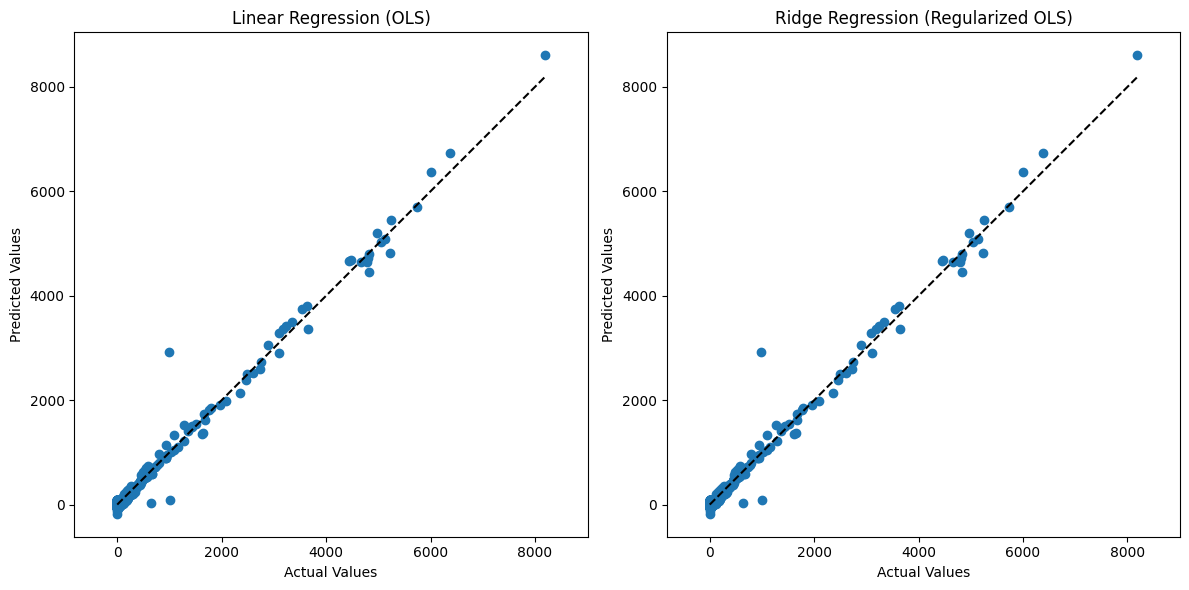

MSE (OLS): 3383.04925352394
MSE (Ridge): 3383.0492535228373


In [7]:
# Ploting the predictions vs actual targets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_ols)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Linear Regression (OLS)")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')  # Diagonal line for reference
plt.axis('equal')

# Plots predictions vs actual targets for Ridge
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_ridge)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Ridge Regression (Regularized OLS)")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')  # Diagonal line for reference
plt.axis('equal')

plt.tight_layout()
plt.show()

# Print MSE results
print("MSE (OLS):", mse_ols)
print("MSE (Ridge):", mse_ridge)


In [8]:
'''References: https://www.geeksforgeeks.org/ordinary-least-squares-ols-using-statsmodels/ https://builtin.com/data-science/ols-regression https://deepai.org/machine-learning-glossary-and-terms/ordinary-least-squares'''

'References: https://www.geeksforgeeks.org/ordinary-least-squares-ols-using-statsmodels/ https://builtin.com/data-science/ols-regression https://deepai.org/machine-learning-glossary-and-terms/ordinary-least-squares'